# Customer Churn Prediction
Identify telecom customers likely to leave so the retention team can prioritize outreach. Churn = Yes is the positive class. This notebook covers data preparation, exploration, feature engineering, decision-tree selection, evaluation, interpretation, and a saved pipeline consumed by the REST API.

The supplied dataset and data dictionary are the sources. All random operations use seed 42. Model selection uses training-only cross-validation; the stratified 30% test set is held out until final evaluation.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import joblib
ROOT = Path.cwd() if (Path.cwd() / 'preprocessing.py').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
from preprocessing import CustomerFeatures, NUMERIC, CATEGORIES, FEATURES, ENGINEERED
SEED = 42
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 30)
df = pd.read_csv(ROOT / 'data' / 'TelcoCustomerChurn.csv')
display(df.head())
print('Dataset shape:', df.shape)
display(pd.read_csv(ROOT / 'data' / 'TelcoCustomerChurn - Data Dictionary.csv'))

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Dataset shape: (7043, 21)


,Column,Data Type,Description,Example / Values
0,customerID,Categorical / ID,Unique identifier for each customer,7590-VHVEG
1,gender,Categorical,Gender of the customer,"Male, Female"
2,SeniorCitizen,Numerical / Binary,Indicates whether the customer is a senior cit...,"0, 1"
3,Partner,Categorical,Whether the customer has a partner,"Yes, No"
4,Dependents,Categorical,Whether the customer has dependents,"Yes, No"
5,tenure,Numerical,Number of months the customer has been with th...,"1, 24, 72"
6,PhoneService,Categorical,Whether the customer has phone service,"Yes, No"
7,MultipleLines,Categorical,Whether the customer has multiple phone lines,"Yes, No, No phone service"
8,InternetService,Categorical,Type of internet service subscribed to,"DSL, Fiber optic, No"
9,OnlineSecurity,Categorical,Whether the customer has online security service,"Yes, No, No internet service"


## 1. Data understanding and preparation
Audit the full dataset for structural quality, then split before exploratory comparisons or learned preprocessing. `customerID` identifies customers and is excluded from predictors. `SeniorCitizen` is categorical despite its integer storage. Blank total charges are treated as missing, not assumed to be zero. Numeric medians and categorical modes are learned inside each training fold. Scaling is unnecessary for a decision tree. One-hot encoding avoids imposing an artificial ordering; the transformer can handle unseen categories.

In [2]:
audit = pd.DataFrame({'dtype': df.dtypes.astype(str), 'missing': df.isna().sum(), 'unique': df.nunique()})
audit['blank_strings'] = [df[c].map(lambda x: isinstance(x, str) and not x.strip()).sum() for c in df]
display(audit)
print('Exact duplicate rows:', df.duplicated().sum())
print('Duplicate customer IDs:', df.customerID.duplicated().sum())
total = pd.to_numeric(df.TotalCharges, errors='coerce')
print('TotalCharges missing after numeric conversion:', total.isna().sum())
display(df.loc[total.isna(), ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])
print('Numerical features:', NUMERIC)
print('Categorical features:', list(CATEGORIES))
display(df.Churn.value_counts().to_frame('count').assign(percentage=lambda x: 100*x['count']/len(df)))
assert not df.customerID.duplicated().any(), 'Resolve customer-level duplicates before splitting.'
assert set(df.Churn.unique()) == {'Yes', 'No'}
X = df[FEATURES].copy()
y = df.Churn.map({'No': 0, 'Yes': 1})
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=SEED, stratify=y)
print('Training:', X_train.shape, 'Test:', X_test.shape)
print('Training churn proportion:', round(y_train.mean(), 4))
assert set(X_train.index).isdisjoint(X_test.index)
eda = CustomerFeatures().fit_transform(X_train)
eda['Churn'] = y_train.map({0: 'No', 1: 'Yes'})
eda['ChurnFlag'] = y_train
display(Markdown('**Observations:** There are no duplicate records or customer IDs. The 11 blank total-charge values belong to customers with zero tenure. Churn is the minority class (about 26.5%), so accuracy alone can hide missed churners. The pipeline retains these customers and imputes total charges using training medians.'))

,dtype,missing,unique,blank_strings
customerID,object,0,7043,0
gender,object,0,2,0
SeniorCitizen,int64,0,2,0
Partner,object,0,2,0
Dependents,object,0,2,0
tenure,int64,0,73,0
PhoneService,object,0,2,0
MultipleLines,object,0,3,0
InternetService,object,0,3,0
OnlineSecurity,object,0,3,0


Exact duplicate rows: 0
Duplicate customer IDs: 0
TotalCharges missing after numeric conversion: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


Numerical features: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


,count,percentage
Churn,,
No,5174,73.463013
Yes,1869,26.536987


Training: (4930, 19) Test: (2113, 19)
Training churn proportion: 0.2653


**Observations:** There are no duplicate records or customer IDs. The 11 blank total-charge values belong to customers with zero tenure. Churn is the minority class (about 26.5%), so accuracy alone can hide missed churners. The pipeline retains these customers and imputes total charges using training medians.

## 2. Exploratory data analysis
The following visualizations use only training customers. Associations describe this dataset and do not establish causes of churn.

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=eda, x='Churn', order=['No', 'Yes'], ax=ax)
ax.set_title('Training customers by churn outcome')
plt.show()
display(Markdown(f'**Insight:** {y_train.mean():.1%} of training customers churn. A model predicting only No would achieve {1-y_train.mean():.1%} accuracy but identify no churners.'))

<Figure size 600x400 with 1 Axes>

**Insight:** 26.5% of training customers churn. A model predicting only No would achieve 73.5% accuracy but identify no churners.

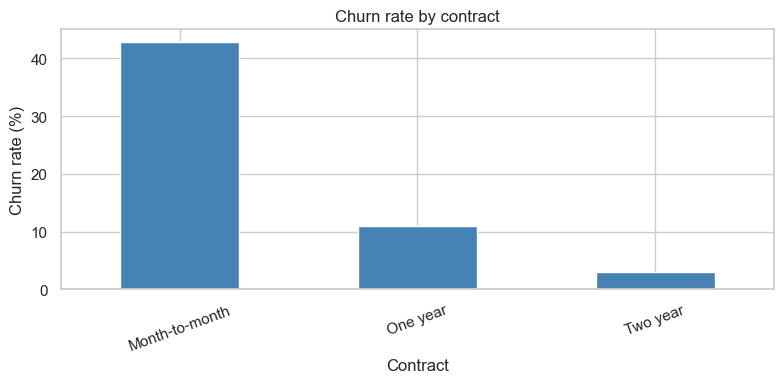

,churn_rate,customers
Contract,,
Month-to-month,0.428624,2704
One year,0.109284,1034
Two year,0.030201,1192


**Insight:** Month-to-month customers have the highest observed churn rate (42.9%). Contract type can help prioritize retention outreach.

In [4]:
def churn_by(column, title):
    summary = eda.groupby(column).ChurnFlag.agg(['mean', 'count']).sort_values('mean', ascending=False)
    fig, ax = plt.subplots(figsize=(8, 4))
    (summary['mean'] * 100).plot.bar(ax=ax, color='steelblue')
    ax.set(title=title, ylabel='Churn rate (%)', xlabel=column)
    ax.tick_params(axis='x', rotation=20)
    plt.tight_layout()
    plt.show()
    display(summary.rename(columns={'mean': 'churn_rate', 'count': 'customers'}))
    return summary
contracts = churn_by('Contract', 'Churn rate by contract')
display(Markdown(f'**Insight:** {contracts.index[0]} customers have the highest observed churn rate ({contracts.iloc[0]["mean"]:.1%}). Contract type can help prioritize retention outreach.'))

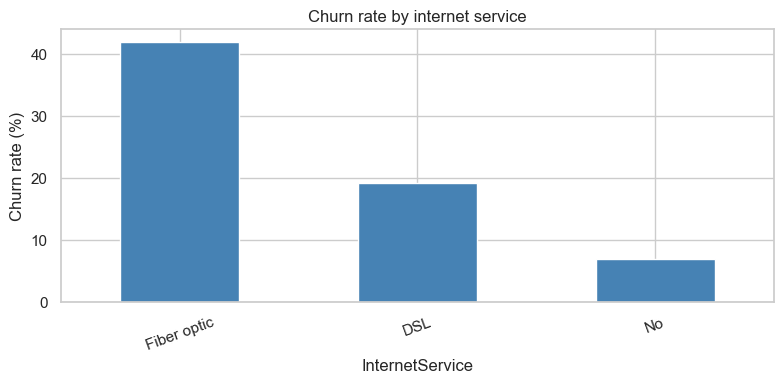

,churn_rate,customers
InternetService,,
Fiber optic,0.418466,2177
DSL,0.191691,1685
No,0.069288,1068


**Insight:** Fiber optic customers have the highest observed churn rate (41.8%); investigate their service experience and pricing before choosing an intervention.

In [5]:
internet = churn_by('InternetService', 'Churn rate by internet service')
display(Markdown(f'**Insight:** {internet.index[0]} customers have the highest observed churn rate ({internet.iloc[0]["mean"]:.1%}); investigate their service experience and pricing before choosing an intervention.'))

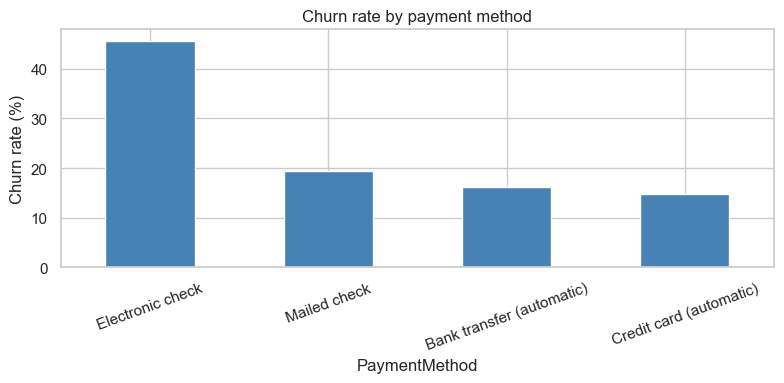

,churn_rate,customers
PaymentMethod,,
Electronic check,0.456469,1654
Mailed check,0.195013,1123
Bank transfer (automatic),0.162983,1086
Credit card (automatic),0.147142,1067


**Insight:** Electronic check has the highest churn rate (45.6%). Payment behaviour may help segment outreach, but changing payment method alone is not proven to prevent churn.

In [6]:
payment = churn_by('PaymentMethod', 'Churn rate by payment method')
display(Markdown(f'**Insight:** {payment.index[0]} has the highest churn rate ({payment.iloc[0]["mean"]:.1%}). Payment behaviour may help segment outreach, but changing payment method alone is not proven to prevent churn.'))

C:\NAGP_2026_Demo\Sanjay_Nandaniya_3213327_NAGP_DS_2026\.venv\Lib\site-packages\seaborn\_core.py:991: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\NAGP_2026_Demo\Sanjay_Nandaniya_3213327_NAGP_DS_2026\.venv\Lib\site-packages\seaborn\_core.py:991: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\NAGP_2026_Demo\Sanjay_Nandaniya_3213327_NAGP_DS_2026\.venv\Lib\site-packages\seaborn\_core.py:991: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_su

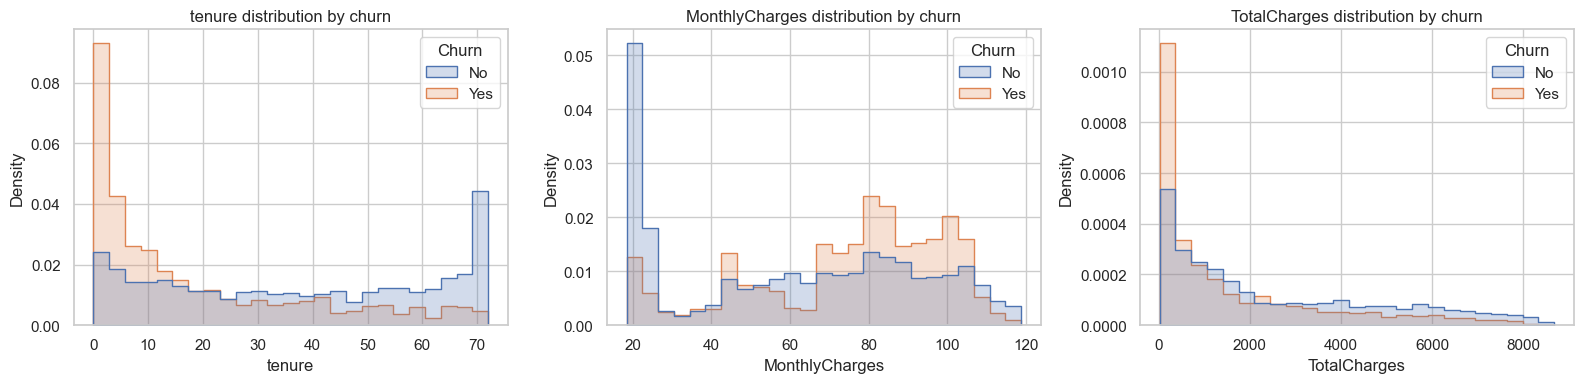

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,38.0,64.45,1679.400
Yes,10.0,80.00,705.075


**Insight:** Compare the class-normalized shapes and medians: churners tend to have shorter tenure and higher monthly charges. Early-tenure customers with large monthly bills deserve attention; total charges also reflect time spent with the company.

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for column, ax in zip(NUMERIC, axes):
    sns.histplot(data=eda, x=column, hue='Churn', stat='density', common_norm=False, bins=25, element='step', ax=ax)
    ax.set_title(column + ' distribution by churn')
plt.tight_layout()
plt.show()
display(eda.groupby('Churn')[NUMERIC].median())
display(Markdown('**Insight:** Compare the class-normalized shapes and medians: churners tend to have shorter tenure and higher monthly charges. Early-tenure customers with large monthly bills deserve attention; total charges also reflect time spent with the company.'))

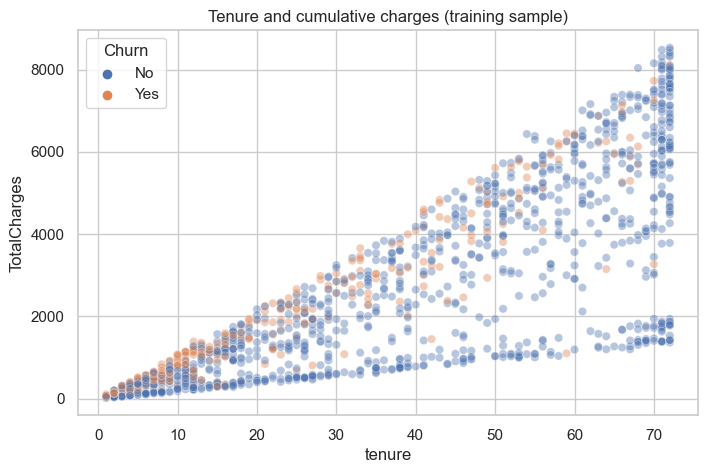

**Insight:** Total charges generally increase with tenure, so they partly measure the same customer history. Low cumulative charges should not automatically be interpreted as low customer value.

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=eda.sample(min(1500, len(eda)), random_state=SEED), x='tenure', y='TotalCharges', hue='Churn', alpha=0.4, ax=ax)
ax.set_title('Tenure and cumulative charges (training sample)')
plt.show()
display(Markdown('**Insight:** Total charges generally increase with tenure, so they partly measure the same customer history. Low cumulative charges should not automatically be interpreted as low customer value.'))

## 3. Feature engineering
1. **SupportServicesCount:** Count Yes values across OnlineSecurity, OnlineBackup, DeviceProtection, and TechSupport (0–4). This summarizes service engagement and access to assistance, which may distinguish retention needs. No internet service contributes zero.
2. **IsNewCustomer:** Set to 1 when tenure is at most 12 months and 0 otherwise. This represents the first-year onboarding period, a potentially useful retention segment. Missing tenure remains missing until training-fitted imputation.

Both features use only information available for the customer at prediction time. They are deterministic, created inside the pipeline, and their usefulness is assessed through training cross-validation rather than assumed.

In [9]:
display(eda[['tenure', 'IsNewCustomer', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'SupportServicesCount']].head())
def make_pipeline(**tree_params):
    preprocessing = ColumnTransformer([
        ('numeric', SimpleImputer(strategy='median'), NUMERIC + ENGINEERED),
        ('categorical', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), list(CATEGORIES))
    ])
    return Pipeline([
        ('features', CustomerFeatures()),
        ('preprocess', preprocessing),
        ('tree', DecisionTreeClassifier(random_state=SEED, **tree_params))
    ])

,tenure,IsNewCustomer,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,SupportServicesCount
5557,5,1.0,No,No,No,No,0
2270,3,1.0,No,No,Yes,No,1
6930,3,1.0,No,No,No,No,0
2257,60,0.0,No,No,Yes,Yes,2
898,12,1.0,Yes,No,No,Yes,2


## 4. Model development
Compare an unrestricted decision tree and a regularized tree, then tune depth, minimum leaf size, and class weights using five-fold stratified cross-validation. All preprocessing is refit within each fold. Class weighting addresses the minority churn class without generating synthetic customers. Selection uses mean cross-validation F1 to balance missed churners against outreach volume; recall is a key business metric but no outreach budget or cost ratio is provided. Predictions use the fitted classifier's default decision rule; the test set is not used to tune thresholds.

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {'accuracy': 'accuracy', 'precision': 'precision', 'recall': 'recall', 'f1': 'f1'}
models = {'Unrestricted tree': make_pipeline(), 'Regularized tree': make_pipeline(max_depth=5, min_samples_leaf=20)}
rows = []
for name, candidate in models.items():
    scores = cross_validate(candidate, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    rows.append({'model': name, **{metric: scores['test_'+metric].mean() for metric in scoring}, 'f1_std': scores['test_f1'].std()})
search = GridSearchCV(make_pipeline(), {
    'tree__max_depth': [3, 5, 7, 10],
    'tree__min_samples_leaf': [10, 30, 60],
    'tree__class_weight': [None, 'balanced']
}, scoring=scoring, refit='f1', cv=cv, n_jobs=1)
search.fit(X_train, y_train)
i = search.best_index_
rows.append({'model': 'Tuned tree', **{metric: search.cv_results_['mean_test_'+metric][i] for metric in scoring}, 'f1_std': search.cv_results_['std_test_f1'][i]})
comparison = pd.DataFrame(rows).set_index('model')
display(comparison.round(4))
print('Best tuning parameters:', search.best_params_)
winner = comparison.f1.idxmax()
final_model = search.best_estimator_ if winner == 'Tuned tree' else models[winner].fit(X_train, y_train)
display(Markdown(f'**Selection:** {winner} has the highest mean training cross-validation F1 ({comparison.loc[winner, "f1"]:.3f}) and is selected. Its CV recall is {comparison.loc[winner, "recall"]:.3f}. The same folds support a consistent comparison; the selected CV result can still be optimistic after tuning, so the untouched test set provides the final estimate.'))

,accuracy,precision,recall,f1,f1_std
model,,,,,
Unrestricted tree,0.7312,0.4939,0.5260,0.5093,0.0123
Regularized tree,0.7901,0.6293,0.5161,0.5636,0.0402
Tuned tree,0.7400,0.5087,0.7844,0.6160,0.0262


Best tuning parameters: {'tree__class_weight': 'balanced', 'tree__max_depth': 5, 'tree__min_samples_leaf': 10}


**Selection:** Tuned tree has the highest mean training cross-validation F1 (0.616) and is selected. Its CV recall is 0.784. The same folds support a consistent comparison; the selected CV result can still be optimistic after tuning, so the untouched test set provides the final estimate.

## 5. Final model evaluation
Evaluate once on the 30% held-out test set. Precision, recall, and F1 refer to churn = Yes. Recall is the business priority: a false negative means a potential departing customer receives no proactive outreach. Precision still matters because unnecessary offers and calls consume resources. Without campaign costs, response rates, and customer value, the model's financial return cannot be quantified.

,Test score
Accuracy,0.7113
Precision,0.4741
Recall,0.7986
F1 Score,0.5950


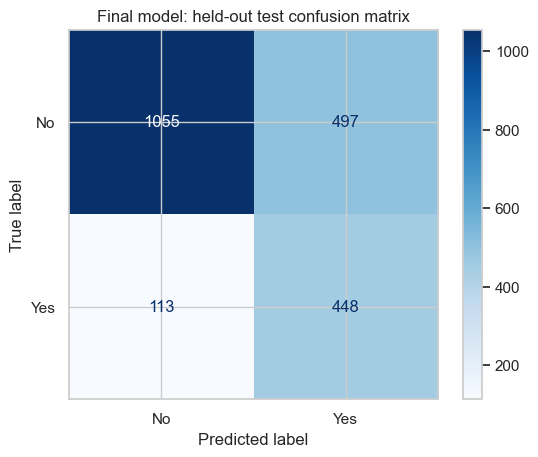

**Business interpretation:** The model identifies **448** of **561** churners (79.9% recall) and misses **113**. It flags **945** customers for contact, including **497** who did not churn. About **47.4%** of flagged customers actually churn. It correctly leaves **1055** non-churners unflagged. Accuracy is **71.1%**, and F1 is **0.595**.

This random split estimates performance on similar customers, not future-period performance. Tree probabilities are leaf-level estimates (affected by class weights if selected), not calibrated guarantees. A retention team should validate interventions before assuming outreach prevents churn.

In [11]:
predictions = final_model.predict(X_test)
metrics = {'Accuracy': accuracy_score(y_test, predictions), 'Precision': precision_score(y_test, predictions, zero_division=0), 'Recall': recall_score(y_test, predictions, zero_division=0), 'F1 Score': f1_score(y_test, predictions, zero_division=0)}
display(pd.Series(metrics, name='Test score').to_frame().round(4))
cm = confusion_matrix(y_test, predictions, labels=[0, 1])
ConfusionMatrixDisplay(cm, display_labels=['No', 'Yes']).plot(cmap='Blues')
plt.title('Final model: held-out test confusion matrix')
plt.show()
tn, fp, fn, tp = cm.ravel()
display(Markdown(f'''**Business interpretation:** The model identifies **{tp}** of **{tp+fn}** churners ({metrics['Recall']:.1%} recall) and misses **{fn}**. It flags **{tp+fp}** customers for contact, including **{fp}** who did not churn. About **{metrics['Precision']:.1%}** of flagged customers actually churn. It correctly leaves **{tn}** non-churners unflagged. Accuracy is **{metrics['Accuracy']:.1%}**, and F1 is **{metrics['F1 Score']:.3f}**.

This random split estimates performance on similar customers, not future-period performance. Tree probabilities are leaf-level estimates (affected by class weights if selected), not calibrated guarantees. A retention team should validate interventions before assuming outreach prevents churn.'''))

The selected tree has lower test accuracy (71.1%) than always predicting No (about 73.5%), but the latter has zero churn recall. The selected model catches about four out of five churners, while slightly fewer than half of its alerts are actual churners. This is a deliberate detection-versus-outreach trade-off, not an improvement on every metric.

## 6. Model interpretation
Impurity-based importance measures how much a feature reduces weighted impurity across the tree. It is not a causal effect and can favor features offering many candidate splits; correlated features can share importance.

,importance
categorical__Contract_Month-to-month,0.609140
numeric__tenure,0.111881
categorical__InternetService_Fiber optic,0.101444
numeric__MonthlyCharges,0.056207
numeric__TotalCharges,0.031504
categorical__OnlineSecurity_No,0.018567
categorical__StreamingMovies_No internet service,0.016497
categorical__TechSupport_No,0.014776
categorical__PaymentMethod_Electronic check,0.014327
categorical__StreamingMovies_Yes,0.006656


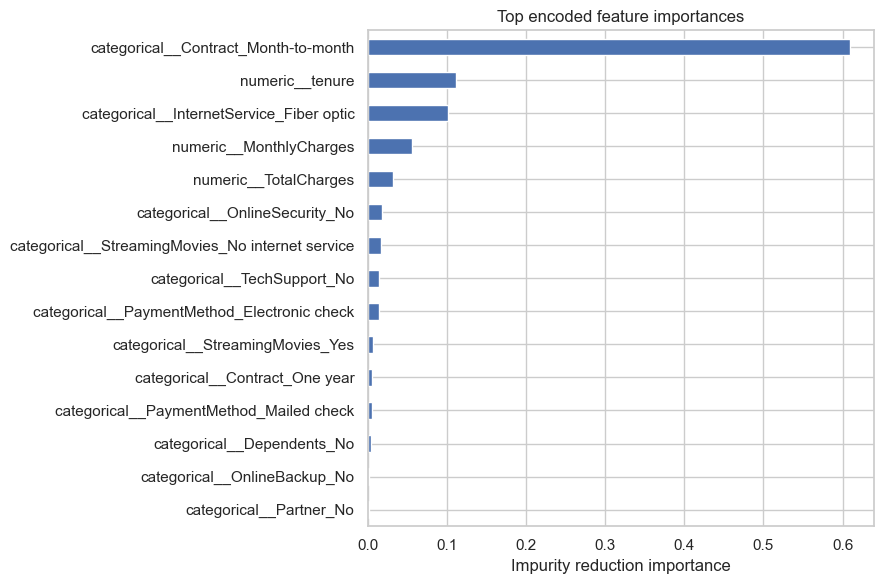

**Key drivers:** The five highest-ranked encoded features are `categorical__Contract_Month-to-month`, `numeric__tenure`, `categorical__InternetService_Fiber optic`, `numeric__MonthlyCharges`, `numeric__TotalCharges`. Their split rules below show how the tree combines customer attributes; importance alone does not give a direction of effect.

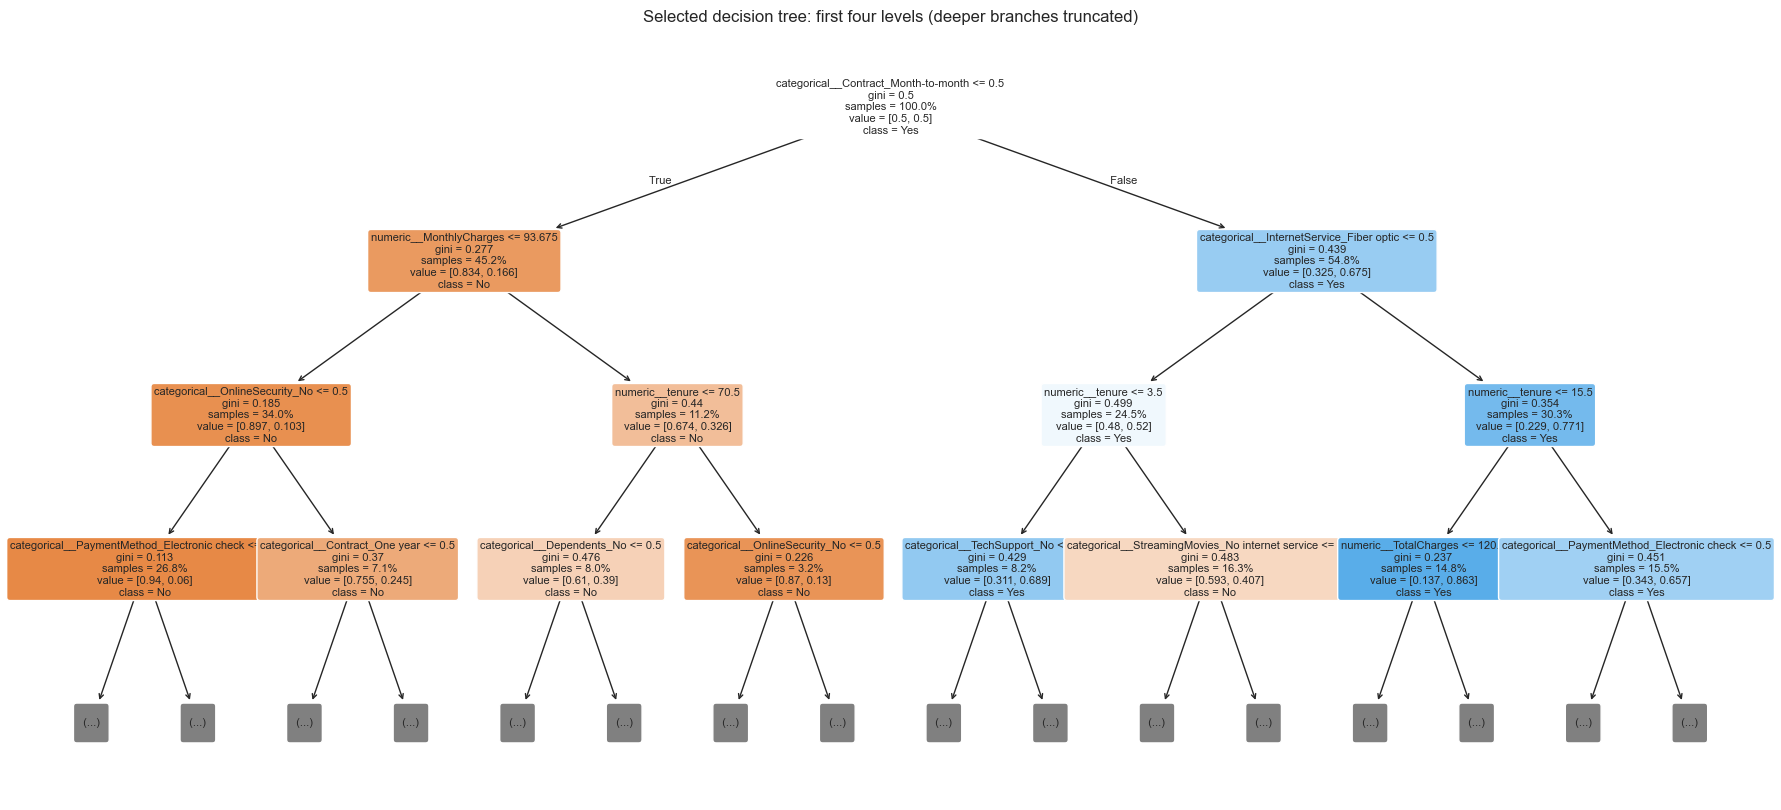

|--- categorical__Contract_Month-to-month <= 0.50
|   |--- numeric__MonthlyCharges <= 93.67
|   |   |--- categorical__OnlineSecurity_No <= 0.50
|   |   |   |--- categorical__PaymentMethod_Electronic check <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- categorical__PaymentMethod_Electronic check >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- categorical__OnlineSecurity_No >  0.50
|   |   |   |--- categorical__Contract_One year <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- categorical__Contract_One year >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |--- numeric__MonthlyCharges >  93.67
|   |   |--- numeric__tenure <= 70.50
|   |   |   |--- categorical__Dependents_No <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- categorical__Dependents_No >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- numeric__tenure >  70.50
|   |   |   |--- categorical__OnlineSe

**Reading the tree:** Follow the left branch when the condition is true and the right branch otherwise. A one-hot contract indicator at or below 0.5 means that contract is absent. Each leaf predicts the class with the larger weighted share; displayed values reflect weighting when class weights are used. These segments can guide contract, onboarding, and service-support conversations, with the intervention chosen after investigating customer needs.

In [12]:
names = final_model.named_steps['preprocess'].get_feature_names_out()
importance = pd.Series(final_model.named_steps['tree'].feature_importances_, index=names).sort_values(ascending=False)
display(importance.head(15).to_frame('importance'))
importance.head(15).sort_values().plot.barh(figsize=(9, 6), title='Top encoded feature importances')
plt.xlabel('Impurity reduction importance')
plt.tight_layout()
plt.show()
display(Markdown('**Key drivers:** The five highest-ranked encoded features are ' + ', '.join('`'+name+'`' for name in importance.head(5).index) + '. Their split rules below show how the tree combines customer attributes; importance alone does not give a direction of effect.'))
plt.figure(figsize=(22, 10))
plot_tree(final_model.named_steps['tree'], feature_names=names, class_names=['No', 'Yes'], filled=True, rounded=True, max_depth=3, fontsize=8, proportion=True)
plt.title('Selected decision tree: first four levels (deeper branches truncated)')
plt.show()
print(export_text(final_model.named_steps['tree'], feature_names=list(names), max_depth=3))
display(Markdown('**Reading the tree:** Follow the left branch when the condition is true and the right branch otherwise. A one-hot contract indicator at or below 0.5 means that contract is absent. Each leaf predicts the class with the larger weighted share; displayed values reflect weighting when class weights are used. These segments can guide contract, onboarding, and service-support conversations, with the intervention chosen after investigating customer needs.'))

## 7. Save the pipeline and verify the API
Save feature engineering, fitted imputation, encoding, and the final tree together. The reusable transformer lives in `preprocessing.py`, so deserialization works in a separate API process. The API accepts one customer object, returns Yes/No and the positive-class probability, and returns HTTP 400 for invalid data.

In [13]:
model_path = ROOT / 'model' / 'churn_model.pkl'
joblib.dump(final_model, model_path)
reloaded = joblib.load(model_path)
np.testing.assert_array_equal(final_model.predict(X_test), reloaded.predict(X_test))
np.testing.assert_allclose(final_model.predict_proba(X_test), reloaded.predict_proba(X_test))
sample = X_test.iloc[0].to_dict()
for column in NUMERIC:
    value = pd.to_numeric(sample[column], errors='coerce')
    sample[column] = None if pd.isna(value) else (int(value) if column == 'tenure' else float(value))
sample['SeniorCitizen'] = int(sample['SeniorCitizen'])
(ROOT / 'sample_request.json').write_text(json.dumps(sample, indent=2), encoding='utf-8')
from app import app
with app.test_client() as client:
    response = client.post('/predict', json=sample)
    assert response.status_code == 200
    body = response.get_json()
    assert body['prediction'] == ('Yes' if reloaded.predict(pd.DataFrame([sample]))[0] else 'No')
    assert abs(body['churn_probability'] - reloaded.predict_proba(pd.DataFrame([sample]))[0, 1]) < 1e-6
    (ROOT / 'sample_response.json').write_text(json.dumps(body, indent=2), encoding='utf-8')
    for invalid in [{}, [], {**sample, 'tenure': -1}, {**sample, 'Contract': 'Unknown'}, {**sample, 'Churn': 'Yes'}, {**sample, 'MonthlyCharges': 'invalid'}]:
        assert client.post('/predict', json=invalid).status_code == 400
    assert client.post('/predict', data='{broken', content_type='application/json').status_code == 400
    assert client.post('/predict', data='plain text').status_code == 400
    assert client.post('/predict', json={**sample, 'TotalCharges': None}).status_code == 200
display(body)
print('Saved pipeline matches original predictions. Valid requests, missing total charges, and invalid inputs verified.')

{'churn_probability': 0.750078, 'prediction': 'Yes'}

Saved pipeline matches original predictions. Valid requests, missing total charges, and invalid inputs verified.
